In [1]:
from datasets import load_dataset

ds = load_dataset("prithivMLmods/Face-Age-10K")

README.md:   0%|          | 0.00/1.16k [00:00<?, ?B/s]

dataset/0000.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9165 [00:00<?, ? examples/s]

In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 9165
    })
})

In [3]:
import pandas as pd

df = ds['train'].to_pandas()
df.head()

,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0


In [4]:
labels_list = [
  'age 01-10',
  'age 11-20',
  'age 21-30',
  'age 31-40',
  'age 41-55',
  'age 56+'
]

df['label'].value_counts()

,count
label,
0,2474
2,1523
1,1181
4,1181
3,1010
5,799
6,653
7,344


In [5]:
import pandas as pd

# 1. Konversi dataset awal Anda menjadi pandas DataFrame (sesuai screenshot Anda)
df = ds['train'].to_pandas()

# 2. HAPUS LABEL 7
df = df[df['label'] != 7]

# 3. UBAH LABEL 6 MENJADI 5
df['label'] = df['label'].replace(6, 5)

# Reset index agar penomoran baris kembali urut setelah ada data yang dihapus
df = df.reset_index(drop=True)

# Menghapus baris indeks 0 hingga 999
df = df.drop(df.index[:1000]).reset_index(drop=True)

print(f"Jumlah data setelah di-drop: {len(df)}")
# 4. Verifikasi hasil perubahan
print("Daftar label yang tersisa saat ini:", df['label'].unique())
print(df['label'].value_counts())
df.head()

Jumlah data setelah di-drop: 7821
Daftar label yang tersisa saat ini: [0 1 2 3 4 5]
label
2    1523
0    1474
5    1452
1    1181
4    1181
3    1010
Name: count, dtype: int64


,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0


In [6]:
from PIL import Image
import io
import pandas as pd

def get_image_size(image_bytes_dict):
    try:
        img_bytes = image_bytes_dict['bytes']
        with Image.open(io.BytesIO(img_bytes)) as img:
            return img.width, img.height
    except:
        return None, None

df[['width', 'height']] = df['image'].apply(get_image_size).tolist()
df['resolution'] = df['width'].astype(str) + 'x' + df['height'].astype(str)

df

,image,label,width,height,resolution
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0,200,200,200x200
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0,200,200,200x200
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0,200,200,200x200
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0,200,200,200x200
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0,200,200,200x200
...,...,...,...,...,...
7816,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5,200,200,200x200
7817,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5,200,200,200x200
7818,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5,200,200,200x200
7819,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5,200,200,200x200


In [7]:
raw_images = [row['bytes'] for idx, row in df['image'].items()]
labels = df['label'].values

In [8]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

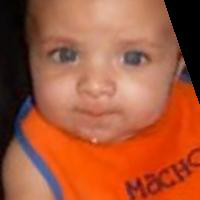

In [9]:
img_bytes = df['image'].iloc[0]['bytes']

nparr = np.frombuffer(img_bytes, np.uint8)

img_opencv = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

cv2_imshow(img_opencv)

In [10]:
X_data = [row['bytes'] for idx, row in df['image'].items()]
y_data = df['label'].values

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data, y_data, test_size=0.20, random_state=42, stratify=y_data
)

In [13]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [14]:
import tensorflow as tf

In [15]:
@tf.function
def gpu_parse_and_preprocess(img_bytes, label):
    image = tf.image.decode_jpeg(img_bytes, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(tf.round(image), tf.uint8)

    return image, label

def create_gpu_dataset(raw_images, labels, batch_size=32, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices((raw_images, labels))

    dataset = dataset.map(gpu_parse_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

In [16]:
train_ds = create_gpu_dataset(X_train, y_train, batch_size=32, is_training=True)
val_ds   = create_gpu_dataset(X_val, y_val, batch_size=32, is_training=False)
test_ds  = create_gpu_dataset(X_test, y_test, batch_size=32, is_training=False)

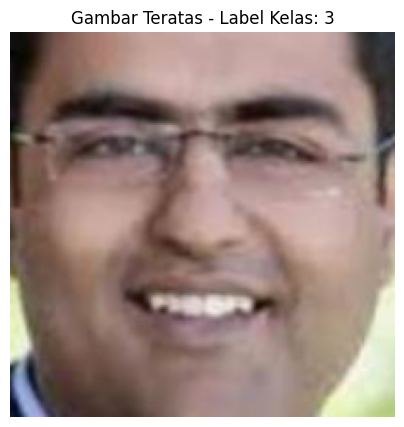

Resolusi gambar : (224, 224, 3)
Tipe data gambar: uint8
Rentang piksel  : 0 sampai 253


In [17]:
import matplotlib.pyplot as plt
# Lakukan pengecekan data teratas
for images, labels in train_ds.take(1):
    # Ambil elemen pertama (indeks 0)
    first_image = images[0].numpy()
    first_label = labels[0].numpy()

    # Ambil indeks label (Gunakan np.argmax jika label berupa One-Hot)
    # Jika label Anda berupa angka biasa, cukup gunakan: label_index = int(first_label)
    label_index = np.argmax(first_label) if first_label.ndim > 0 else int(first_label)

    # Tampilkan gambar menggunakan Matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(first_image)  # Karena bertipe uint8 (0-255), Matplotlib pasti merender dengan normal
    plt.title(f"Gambar Teratas - Label Kelas: {label_index}")
    plt.axis('off')
    plt.show()

    # Cetak info properti untuk memastikan kepatuhan model
    print(f"Resolusi gambar : {first_image.shape}")
    print(f"Tipe data gambar: {first_image.dtype}")
    print(f"Rentang piksel  : {first_image.min()} sampai {first_image.max()}")
    break

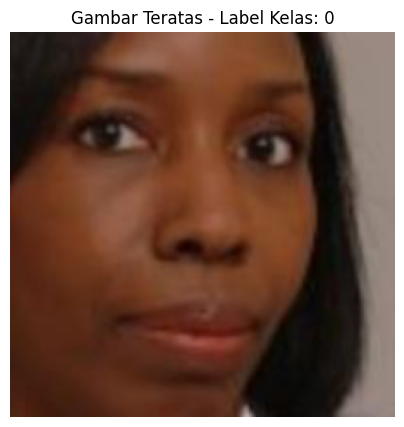

Resolusi gambar : (224, 224, 3)
Rentang piksel  : 0 sampai 188


In [18]:
import numpy as np

# 1. Mengambil batch pertama dari train_ds
for images, labels in train_ds.take(1):

    # 2. Konversi tensor GPU ke array NumPy agar bisa dirender oleh CPU & Matplotlib
    first_image = images[0].numpy()
    first_label = labels[0].numpy()

    # 3. Ambil nilai indeks kelas asli (misal: format one-hot [1,0,0,0,0,0,0,0] -> indeks 0)
    # Catatan: Jika Anda menggunakan sparse_categorical_crossentropy (tanpa one-hot),
    # langsung gunakan: label_index = int(first_label)
    label_index = np.argmax(first_label)

    # 4. Tampilkan gambar teratas
    plt.figure(figsize=(5, 5))
    plt.imshow(first_image)
    plt.title(f"Gambar Teratas - Label Kelas: {label_index}")
    plt.axis('off') # Menghilangkan koordinat/grid aksis
    plt.show()

    # 5. Cek informasi properti gambar teratas
    print(f"Resolusi gambar : {first_image.shape}") # Harus (224, 224, 3)
    print(f"Rentang piksel  : {first_image.min()} sampai {first_image.max()}") # Harus 0.0 sampai 1.0 jika normalisasi sukses

    # Break diperlukan agar perulangan berhenti setelah batch pertama terambil
    break

In [19]:
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), weights))

In [21]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.1)
])

In [37]:
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)


In [38]:
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

inputs = layers.Input(shape=(224, 224, 3))
# x = data_augmentation(inputs)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(6, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         5,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,005,958 (11.47 MB)

 Trainable params: 1,602,406 (6.11 MB)

 Non-trainable params: 1,403,552 (5.35 MB)

In [39]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.00004),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [46]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/60
 52/196 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.8465 - loss: 0.4426

KeyboardInterrupt: 

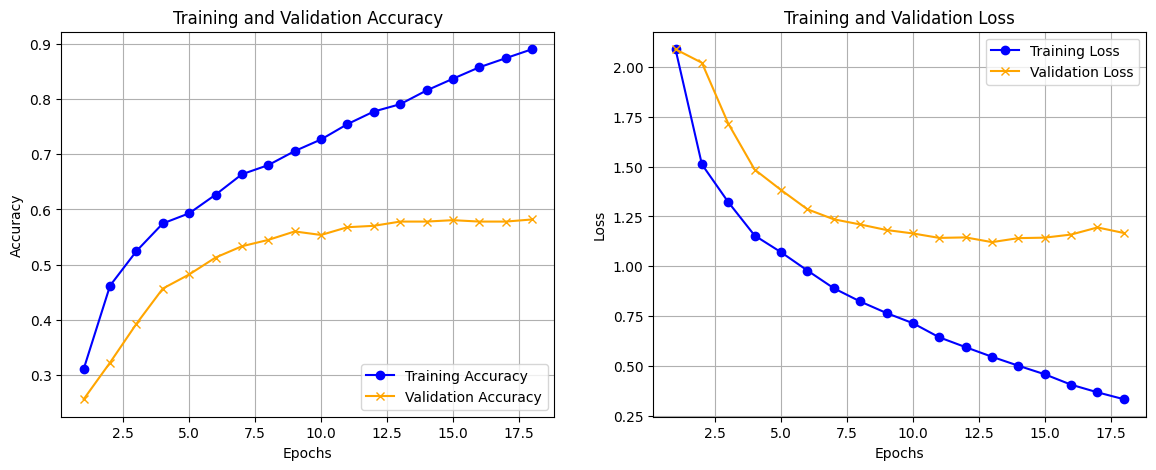

In [42]:
import matplotlib.pyplot as plt

# Asumsi: 'history' adalah variabel hasil dari model.fit()
# Contoh: history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs)

# Ambil data dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Membuat figure untuk plot
plt.figure(figsize=(14, 5))

# 1. Plot Grafik Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='x')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Plot Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Menampilkan grafik
plt.show()

In [43]:
# Asumsi: 'model' adalah nama variabel model yang sudah Anda train sebelumnya

print("Melakukan evaluasi pada data testing...")
evaluation_results = model.evaluate(test_ds)

# Menampilkan hasil
# Jika model menggunakan metrik accuracy, indeks 0 adalah Loss, indeks 1 adalah Accuracy
print(f"\nTest Loss     : {evaluation_results[0]:.4f}")
print(f"Test Accuracy : {evaluation_results[1]*100:.2f}%")

Melakukan evaluasi pada data testing...
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.5798 - loss: 1.1071

Test Loss     : 1.1071
Test Accuracy : 57.98%


In [47]:
# 2. Inisialisasi Converter dari model Keras
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. (Opsional namun Sangat Direkomendasikan) Optimasi / Kuantisasi
# Ini akan memperkecil ukuran file model hingga 4x lipat (menjadi sekitar 4-5 MB)
# dan mempercepat performa deteksi di HP tanpa banyak mengurangi akurasi.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 4. Proses Konversi Model
tflite_model = converter.convert()

# 5. Simpan hasil konversi menjadi file berkas .tflite
tflite_model_path = 'mobilenetv3large.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"Sukses! Model TFLite berhasil diekstrak dan disimpan di: {tflite_model_path}")

Saved artifact at '/tmp/tmpms72zkx9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_423')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  136075254173328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254172752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254173904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254173520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254173712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254173136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254172944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254170064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254171408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136075254175056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1360752541